# Классификация типа опухоли по матрице экспрессии генов (RNA-seq / gene expression) 


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42


## 1) Загрузка данных

- `data.csv` — матрица экспрессии (`samples x genes`), где индекс — `sample_*`
- `labels.csv` — файл с метками, где индекс — `sample_*`, колонка метки — `Class`

In [ ]:
DATA_PATH = "data.csv"
LABELS_PATH = "labels.csv"

X_df = pd.read_csv(DATA_PATH, index_col=0)
labels_df = pd.read_csv(LABELS_PATH, index_col=0)

if X_df.index.has_duplicates:
    raise ValueError("В data.csv есть дубли sample_id в индексе")
if labels_df.index.has_duplicates:
    raise ValueError("В labels.csv есть дубли sample_id в индексе")
if "Class" not in labels_df.columns:
    raise ValueError("В labels.csv ожидается колонка 'Class'")

common_ids = X_df.index.intersection(labels_df.index, sort=False)
if len(common_ids) == 0:
    raise ValueError("Нет общих sample_id между data.csv и labels.csv")

dropped_from_data = len(X_df) - len(common_ids)
dropped_from_labels = len(labels_df) - len(common_ids)
if dropped_from_data > 0 or dropped_from_labels > 0:
    print(f"Dropped samples -> data: {dropped_from_data}, labels: {dropped_from_labels}")

df = X_df.loc[common_ids].copy()
df["type"] = labels_df.loc[common_ids, "Class"].astype(str).values

print("Merged shape:", df.shape)
df.head()


Merged shape: (801, 20532)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,type
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [43]:
print("Shape:", df.shape)
print(df.columns[:10], "...")
print("Target classes:", df["type"].nunique())
df["type"].value_counts().head(20)


Shape: (801, 20532)
Index(['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6',
       'gene_7', 'gene_8', 'gene_9'],
      dtype='object') ...
Target classes: 5


type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

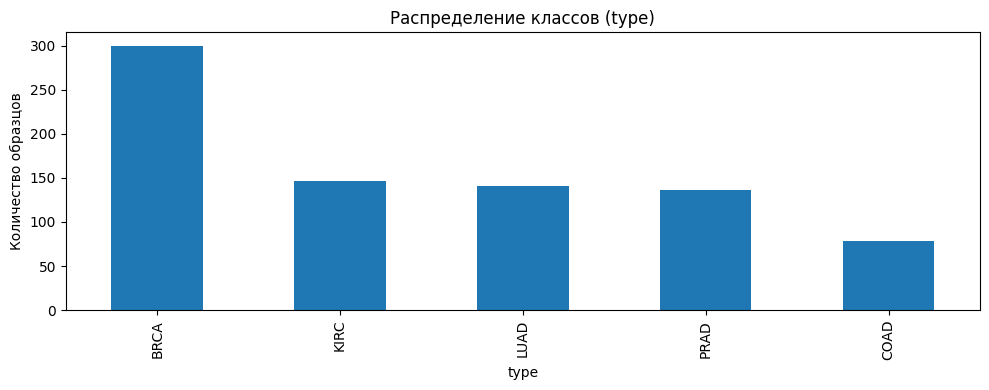

In [ ]:
counts = df["type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
counts.plot(kind="bar")
plt.title("Распределение классов (type)")
plt.ylabel("Количество образцов")
plt.tight_layout()
plt.show()


## 2) Разделение на train/test


In [ ]:
y = df["type"].astype(str)
X = df.drop(columns=["type"])

for col in ["samples", "sample", "id", "patient_id"]:
    if col in X.columns:
        X = X.drop(columns=[col])

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Classes:", list(le.classes_))


Train: (640, 20531) Test: (161, 20531)
Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
display(X_train.head(3))


X_train shape: (640, 20531)
X_test shape: (161, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_391,0.0,4.094565,4.704501,7.545559,9.752299,0.0,8.595821,0.859970,0.0,0.0,...,4.598568,7.654557,10.089887,7.107677,8.832156,12.816038,9.317229,9.461801,9.258929,0.0
sample_148,0.0,6.237034,5.043235,6.297397,10.391415,0.0,7.669941,0.913033,0.0,0.0,...,5.669299,8.437523,10.524503,1.467801,9.666187,11.258572,10.062033,9.018030,7.737159,0.0
sample_595,0.0,3.028304,2.156138,6.459537,9.488378,0.0,5.319195,0.000000,0.0,0.0,...,6.436851,8.557640,9.749657,5.406037,10.590297,11.449572,9.303614,9.228160,4.403943,0.0


## 3) Препроцессинг + Feature selection + SMOTE + модель

Почему так:
- Данные высокоразмерные → **сначала** фильтр по дисперсии и top‑K по ANOVA (**SelectKBest**)  
- SMOTE в высоких размерностях может работать нестабильно, поэтому обычно **сначала** уменьшаем пространство признаков.
- Используем `imblearn.Pipeline`, чтобы SMOTE выполнялся **только внутри train‑фолда** в CV.


In [ ]:
numeric_features = X_train.columns.tolist()
n_train, n_features_total = X_train.shape
n_classes = len(np.unique(y_train))

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

var_selector = VarianceThreshold(threshold=0.0)

FAST_MODE = False
if FAST_MODE:
    K_CANDIDATES = [500, 1000, 1500, 2000]
else:
    K_CANDIDATES = [300, 500, 800, 1200, 2000, 3000, 5000]

K_CANDIDATES = [k for k in K_CANDIDATES if 1 <= k <= n_features_total]
if not K_CANDIDATES:
    K_CANDIDATES = [min(500, n_features_total)]

kbest_selector = SelectKBest(score_func=f_classif, k=K_CANDIDATES[0])

print(f"Train samples: {n_train}, features: {n_features_total}, classes: {n_classes}")
print("SelectKBest candidates (k):", K_CANDIDATES)

smote = SMOTE(
    sampling_strategy="not majority",  
    k_neighbors=5,
    random_state=RANDOM_STATE
)


Train samples: 640, features: 20531, classes: 5
SelectKBest candidates (k): [300, 500, 800, 1200, 2000, 3000, 5000]


## 4) Подбор признаков и сравнение моделей (GridSearchCV)

Метрика для подбора: `f1_macro` (хорошо при дисбалансе, учитывает все классы).  
Также считаем `balanced_accuracy` и `MCC` на тесте.

Мы также подбираем `kbest__k` (число признаков после `SelectKBest`) по CV


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


models = {
    "logreg": LogisticRegression(
        max_iter=2000,
        solver="saga",
        multi_class="multinomial",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "linsvc": LinearSVC(random_state=RANDOM_STATE),
    "extratrees": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "hgb": HistGradientBoostingClassifier(random_state=RANDOM_STATE)
}

param_grids = {
    "logreg": {
        "kbest__k": K_CANDIDATES,
        "model__C": [0.1, 1.0, 3.0],
        "model__penalty": ["l2", "l1"]
    },
    "linsvc": {
        "kbest__k": K_CANDIDATES,
        "model__C": [0.1, 1.0, 3.0]
    },
    "extratrees": {
        "kbest__k": K_CANDIDATES,
        "model__n_estimators": [300],
        "model__max_depth": [None, 30],
        "model__min_samples_leaf": [1, 3]
    },
    "hgb": {
        "kbest__k": K_CANDIDATES,
        "model__max_depth": [None, 6],
        "model__learning_rate": [0.05, 0.1],
        "model__max_iter": [200, 400]
    }
}

results = []
best_estimators = {}

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ("preprocess", preprocess),
        ("var", var_selector),
        ("kbest", kbest_selector),
        ("smote", smote),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    results.append({
        "model": name,
        "best_f1_macro_cv": grid.best_score_,
        "best_k": grid.best_params_.get("kbest__k"),
        "best_params": grid.best_params_
    })

    print(f"[{name}] best_k={grid.best_params_.get('kbest__k')} | f1_macro={grid.best_score_:.4f}")

pd.DataFrame(results).sort_values("best_f1_macro_cv", ascending=False)


Fitting 5 folds for each of 42 candidates, totalling 210 fits


c:\Users\kaa21\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[logreg] best_k=300 | f1_macro=1.0000
Fitting 5 folds for each of 21 candidates, totalling 105 fits
[linsvc] best_k=300 | f1_macro=1.0000
Fitting 5 folds for each of 28 candidates, totalling 140 fits
[extratrees] best_k=500 | f1_macro=0.9974
Fitting 5 folds for each of 56 candidates, totalling 280 fits
[hgb] best_k=800 | f1_macro=0.9952


,model,best_f1_macro_cv,best_k,best_params
0,logreg,1.000000,300,"{'kbest__k': 300, 'model__C': 0.1, 'model__pen..."
1,linsvc,1.000000,300,"{'kbest__k': 300, 'model__C': 0.1}"
2,extratrees,0.997356,500,"{'kbest__k': 500, 'model__max_depth': None, 'm..."
3,hgb,0.995213,800,"{'kbest__k': 800, 'model__learning_rate': 0.1,..."


## 5) Финальная оценка моделей

- считаем единый набор метрик: `Top-1 accuracy`, `precision/recall/F1 (macro)`, `balanced accuracy`
- строим `confusion matrix` и `row-normalized confusion matrix` для каждой модели


Best classical by CV: logreg
Best classical params: {'kbest__k': 300, 'model__C': 0.1, 'model__penalty': 'l2'}


,model,accuracy_top1,precision_macro,recall_macro,f1_macro,balanced_accuracy,mcc
0,linsvc,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,logreg,0.9938,0.9967,0.9929,0.9947,0.9929,0.9918
2,extratrees,0.9876,0.9935,0.9857,0.9893,0.9857,0.9838
3,hgb,0.9752,0.9797,0.9658,0.9723,0.9658,0.9673


Model selected for detailed analysis: linsvc


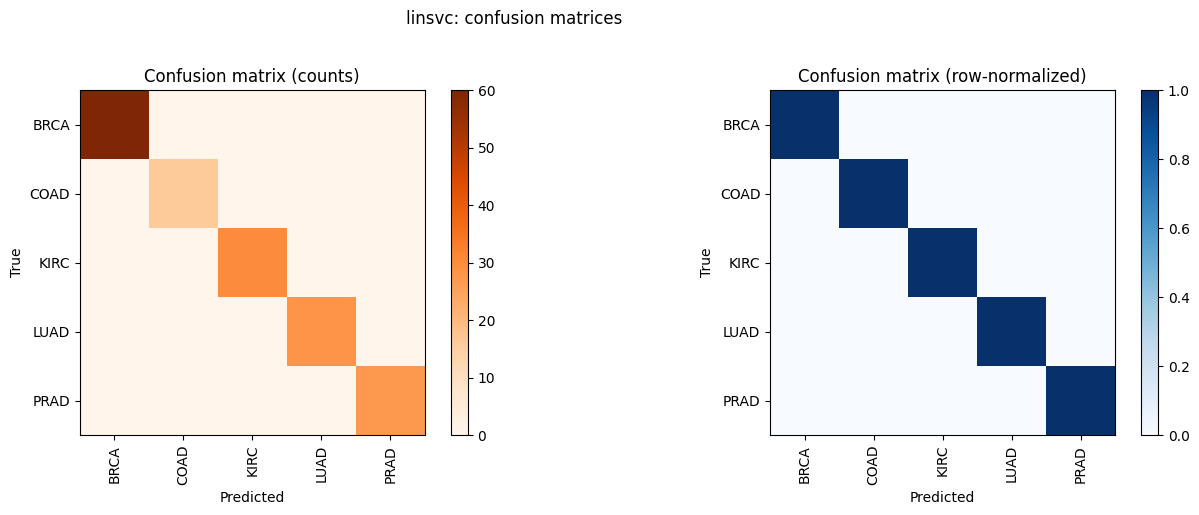

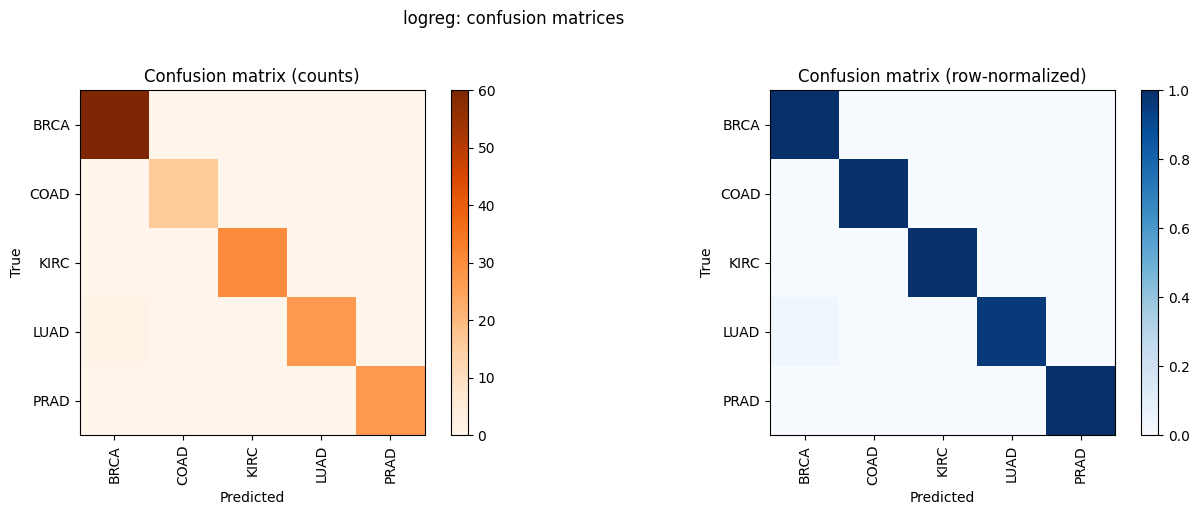

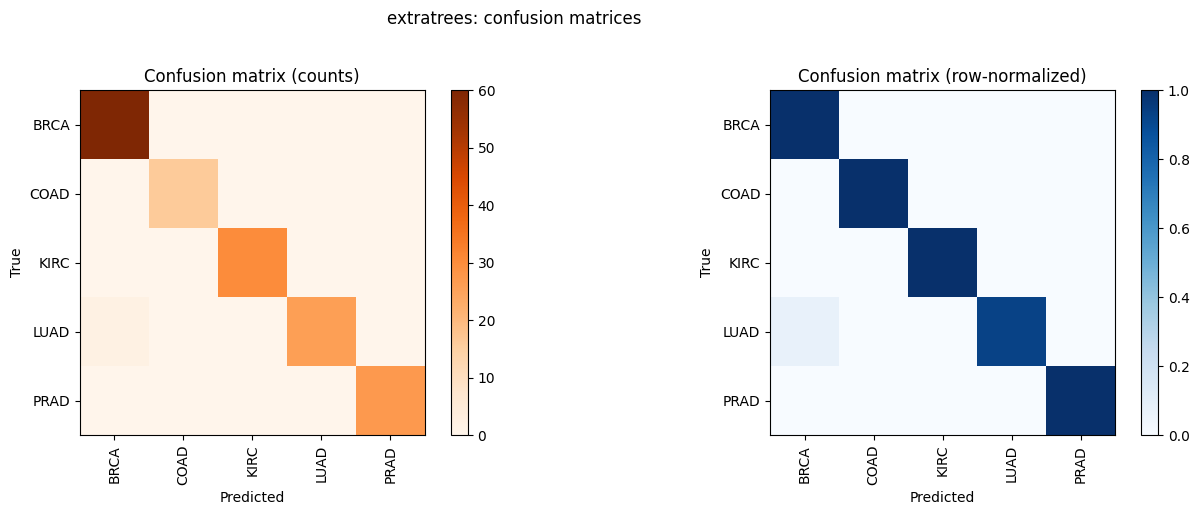

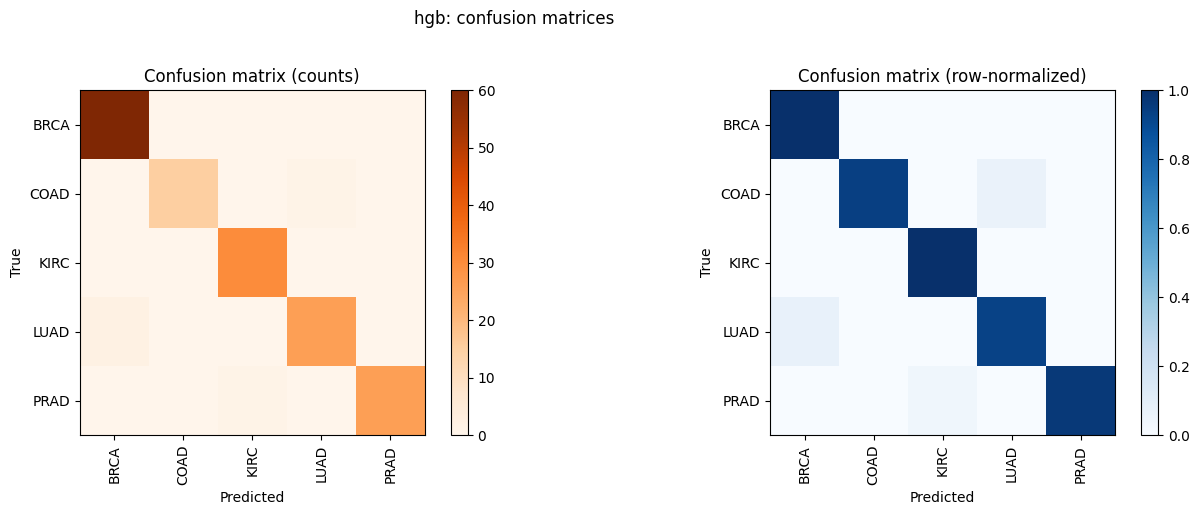

In [57]:
import copy
from sklearn.base import clone

res_df = pd.DataFrame(results).sort_values("best_f1_macro_cv", ascending=False).reset_index(drop=True)
best_name = res_df.iloc[0]["model"]
best_model = best_estimators[best_name]

print("Best classical by CV:", best_name)
print("Best classical params:", res_df.iloc[0]["best_params"])

def _decision_to_confidence(model, X):
    """Пытаемся извлечь confidence для моделей без predict_proba (например, LinearSVC)."""
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        return probs.max(axis=1)

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        if scores.ndim == 1: 
            scores = np.c_[-scores, scores]
        scores = scores - scores.max(axis=1, keepdims=True)
        probs = np.exp(scores)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return probs.max(axis=1)

    return None

def evaluate_predictions(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy_top1": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

def plot_confusion_pair(cm_model, class_names, model_name):
    cm_norm = cm_model.astype(float) / np.maximum(cm_model.sum(axis=1, keepdims=True), 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name}: confusion matrices", y=1.02)

    im0 = axes[0].imshow(cm_model, interpolation="nearest", cmap="Oranges")
    axes[0].set_title("Confusion matrix (counts)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(cm_norm, interpolation="nearest", cmap="Blues")
    axes[1].set_title("Confusion matrix (row-normalized)")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    ticks = np.arange(len(class_names))
    for ax in axes:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(class_names, rotation=90)
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

metrics_rows = []
test_predictions = {}
test_conf_matrices = {}
test_confidences = {}
trained_models = dict(best_estimators)

for model_name, model_obj in best_estimators.items():
    pred = model_obj.predict(X_test)
    cm_model = confusion_matrix(y_test, pred, labels=np.arange(len(le.classes_)))

    metrics_rows.append(evaluate_predictions(model_name, y_test, pred))
    test_predictions[model_name] = pred
    test_conf_matrices[model_name] = cm_model
    test_confidences[model_name] = _decision_to_confidence(model_obj, X_test)

metrics_df = pd.DataFrame(metrics_rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(metrics_df.style.format({
    "accuracy_top1": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "f1_macro": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "mcc": "{:.4f}"
}))

analysis_model_name = metrics_df.iloc[0]["model"]
print("Model selected for detailed analysis:", analysis_model_name)

for model_name in metrics_df["model"]:
    plot_confusion_pair(test_conf_matrices[model_name], le.classes_, model_name)


In [66]:
best_model = best_estimators['linsvc']

## 6) Оценка важности признаков


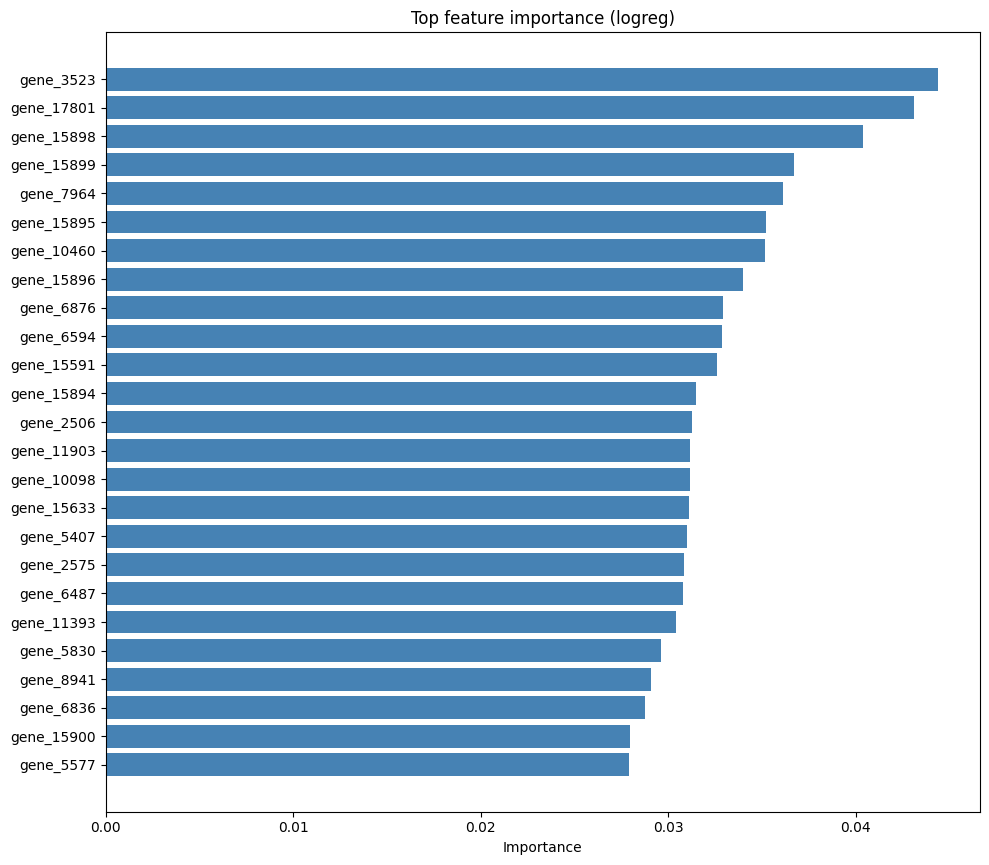

,feature,importance
0,gene_3523,0.044399
1,gene_17801,0.043126
2,gene_15898,0.040381
3,gene_15899,0.036706
4,gene_7964,0.036130
5,gene_15895,0.035185
6,gene_10460,0.035150
7,gene_15896,0.034007
8,gene_6876,0.032936
9,gene_6594,0.032877


In [67]:
from feature_utils import (
    plot_top_feature_importance,
)

selected_feature_names = get_selected_feature_names(best_model, numeric_features)
model_core = best_model.named_steps["model"]

try:
    imp_df = plot_top_feature_importance(
        model_core,
        selected_feature_names,
        top_n=25,
        title=f"Top feature importance ({best_name})"
    )
    display(imp_df.head(20))
except ValueError as e:
    print("Direct feature importance is unavailable for this estimator:", e)
